In [1]:
import sys
from pathlib import Path

current_dir = Path.cwd()

root_dir = current_dir
while not (root_dir / 'utils').is_dir() and root_dir != root_dir.parent:
    root_dir = root_dir.parent

if str(root_dir) not in sys.path:
    sys.path.insert(0, str(root_dir))

In [2]:
from utils.custom_hyperparameter_tunning import CustomGridSearchCV
from utils.custom_cv import CustomKFold
from utils.model_manager import save_model_package

 Train Logistic Regression


## Import required libraries

In [3]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import issparse

# Logistic Regression and model tuning
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, cross_val_score

# Model evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

## Load Training and Test Data
Load the final feature-engineered datasets prepared in the previous stage. These datasets will be used for training and evaluating the Logistic Regression model.

In [4]:
# Load features and target variables
X_train = joblib.load('./data/ready_for_train/X_train_final.pkl')
X_test = joblib.load('./data/ready_for_train/X_test_final.pkl')

y_train = joblib.load('./data/ready_for_train/y_train.pkl')
y_test = joblib.load('./data/ready_for_train/y_test.pkl')

# Check dataset shapes
print('X_train:', X_train.shape)
print('X_test :', X_test.shape)
print('y_train:', y_train.shape)
print('y_test :', y_test.shape)

X_train: (21906, 5001)
X_test : (5477, 5001)
y_train: (21906,)
y_test : (5477,)


## Check Class Distribution

Label
0    11540
1    10366
Name: count, dtype: int64


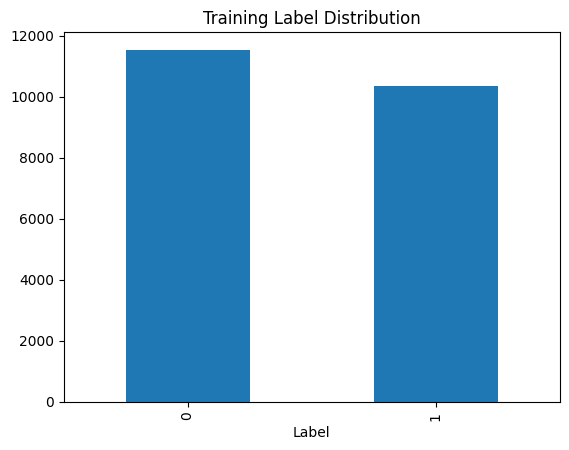

In [5]:
# Count samples in each class
label_distribution = pd.Series(y_train).value_counts()

print(label_distribution)

# Visualize class balance in the training set
label_distribution.plot(kind='bar')
plt.title('Training Label Distribution')
plt.show()

## Logistic Regression Implementation from Scratch

This section implements Logistic Regression using NumPy and Gradient Descent without relying on scikit-learn. The model learns the optimal weights by minimizing Binary Cross-Entropy Loss and is used for binary classification.

In [ ]:
class LogisticRegressionScratch:

    def __init__(self, learning_rate=0.1, epochs=500):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None
        self.loss_history = []
    
    def get_params(self, deep=True):
        return {
            "learning_rate": self.learning_rate,
            "epochs": self.epochs
        }
        
    def set_params(self, **parameters):
        for parameter, value in parameters.items():
            setattr(self, parameter, value)
        return self

    # Sigmoid activation function
    def sigmoid(self, z):
        z = np.clip(z, -250, 250)
        return 1 / (1 + np.exp(-z))

    # Binary cross-entropy loss
    def compute_loss(self, y_true, y_pred):
        eps = 1e-15
        y_pred = np.clip(y_pred, eps, 1 - eps)
        return -np.mean(y_true*np.log(y_pred) + (1-y_true)*np.log(1-y_pred))

    # Train the model using gradient descent
    def fit(self, X, y):
        y = np.array(y).flatten()
        n_samples, n_features = X.shape

        self.weights = np.zeros(n_features)
        self.bias = 0
        self.loss_history = []

        for epoch in range(self.epochs):
            linear = X.dot(self.weights) + self.bias
            pred = self.sigmoid(linear)

            dw = (1 / n_samples) * X.T.dot(pred - y)
            db = (1 / n_samples) * np.sum(pred - y)

            # Update parameters
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            loss = self.compute_loss(y, pred)
            self.loss_history.append(loss)
            
        return self

    # Return predicted probabilities
    def predict_proba(self, X):
        linear = X.dot(self.weights) + self.bias
        return self.sigmoid(linear)

    # Convert probabilities to class labels
    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

In [9]:
param_grid = {
    'learning_rate': [0.1, 0.01, 0.001],  
    'epochs': [500, 1000, 2000]          
}

In [10]:
cv = CustomKFold(n_splits=3, shuffle=True, random_state=42)

lr_model = LogisticRegressionScratch()

grid_search = CustomGridSearchCV(
    estimator=lr_model, 
    param_grid=param_grid, 
    cv=cv, 
    scoring='f1'
)
grid_search.fit(X_train, y_train)

Bắt đầu GridSearchCV: 9 tổ hợp tham số, 3 folds.
[1/9] Params: {'learning_rate': 0.1, 'epochs': 500} --> f1: 0.8064
[2/9] Params: {'learning_rate': 0.1, 'epochs': 1000} --> f1: 0.8422
[3/9] Params: {'learning_rate': 0.1, 'epochs': 2000} --> f1: 0.8924
[4/9] Params: {'learning_rate': 0.01, 'epochs': 500} --> f1: 0.0000
[5/9] Params: {'learning_rate': 0.01, 'epochs': 1000} --> f1: 0.0044
[6/9] Params: {'learning_rate': 0.01, 'epochs': 2000} --> f1: 0.4839
[7/9] Params: {'learning_rate': 0.001, 'epochs': 500} --> f1: 0.0000
[8/9] Params: {'learning_rate': 0.001, 'epochs': 1000} --> f1: 0.0000
[9/9] Params: {'learning_rate': 0.001, 'epochs': 2000} --> f1: 0.0000

-> Tham số TỐT NHẤT: {'learning_rate': 0.1, 'epochs': 2000}
-> Điểm f1 TỐT NHẤT: 0.8924


In [13]:
best_lr_model = grid_search.best_estimator_
best_lr_params = grid_search.best_params_

In [14]:
probs = best_lr_model.predict_proba(X_test).flatten()

candidate_thresholds = np.linspace(0.5, 0.999, 100)

target_threshold = 0.5
closest_fpr = 1.0

print(f"{'Threshold':<12}{'FP':<8}{'TN':<8}{'FPR (%)':<12}{'TPR (Recall) (%)':<15}")
print("-" * 55)

for th in candidate_thresholds:
    preds = (probs >= th).astype(int)
    
    tp_c = np.sum((y_test == 1) & (preds == 1))
    fp_c = np.sum((y_test == 0) & (preds == 1))
    tn_c = np.sum((y_test == 0) & (preds == 0))
    fn_c = np.sum((y_test == 1) & (preds == 0))
    
    fpr_c = fp_c / (fp_c + tn_c) if (fp_c + tn_c) > 0 else 0
    tpr_c = tp_c / (tp_c + fn_c) if (tp_c + fn_c) > 0 else 0
    
    if 0.005 <= fpr_c <= 0.04:
        print(f"{th:<12.4f}{fp_c:<8}{tn_c:<8}{fpr_c*100:<12.2f}{tpr_c*100:<15.2f}")
        
    if abs(fpr_c - 0.01) < abs(closest_fpr - 0.01):
        closest_fpr = fpr_c
        target_threshold = th

print(f"Threshold tốt nhất: {target_threshold:.4f}")
print(f"FPR đạt được tại threshold đso: {closest_fpr*100:.2f}%")

Threshold   FP      TN      FPR (%)     TPR (Recall) (%)
-------------------------------------------------------
0.5403      107     2778    3.71        80.44          
0.5454      98      2787    3.40        78.86          
0.5504      85      2800    2.95        77.43          
0.5554      68      2817    2.36        76.31          
0.5605      61      2824    2.11        74.88          
0.5655      51      2834    1.77        73.23          
0.5706      44      2841    1.53        71.26          
0.5756      39      2846    1.35        68.94          
0.5806      35      2850    1.21        67.32          
0.5857      28      2857    0.97        65.51          
0.5907      27      2858    0.94        63.73          
0.5958      26      2859    0.90        61.92          
0.6008      23      2862    0.80        59.65          
0.6058      21      2864    0.73        57.02          
0.6109      19      2866    0.66        54.48          
0.6159      17      2868    0.59        52.12  

In [15]:
y_pred = best_lr_model.predict(X_test,0.5857)

In [16]:
metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1_Score': f1_score(y_test, y_pred)
}
print(f"Precision : {metrics['Precision']:.4f}")
print(f"Accuracy  : {metrics['Accuracy']:.4f}")
print(f"Recall    : {metrics['Recall']:.4f}")
print(f"F1 Score  : {metrics['F1_Score']:.4f}")

Precision : 0.9838
Accuracy  : 0.8317
Recall    : 0.6551
F1 Score  : 0.7865


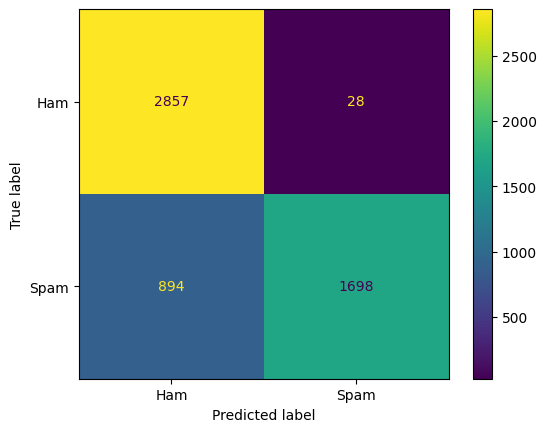

In [17]:
cm = confusion_matrix(y_test, y_pred)

# Visualize prediction results
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Ham', 'Spam']
).plot()

plt.show()

In [18]:
save_model_package(
    model=best_lr_model,                                  
    model_name="Logistic Regression",    
    best_params=best_lr_params,
    metrics=metrics
)

'models\\Logistic_Regression.pkl'

### Training the Model built from scratch

Initialize and train the custom Logistic Regression model using the training dataset. After training, predictions are generated on the test set for performance evaluation.

In [7]:
# Initialize the model with predefined hyperparameters
scratch_model = LogisticRegressionScratch(
    learning_rate=0.1,
    epochs=500
)

# Train the model on the training set
scratch_model.fit(X_train, y_train)

# Generate predictions on the test set
scratch_pred = scratch_model.predict(X_test)

### Evaluating the Scratch Model

Evaluate the performance of the custom Logistic Regression model using common classification metrics, including Accuracy, Precision, Recall, and F1-Score.

In [8]:
# Calculate classification metrics
scratch_accuracy = accuracy_score(y_test, scratch_pred)
scratch_precision = precision_score(y_test, scratch_pred)
scratch_recall = recall_score(y_test, scratch_pred)
scratch_f1 = f1_score(y_test, scratch_pred)

# Display model performance
print(f'Accuracy : {scratch_accuracy:.4f}')
print(f'Precision: {scratch_precision:.4f}')
print(f'Recall   : {scratch_recall:.4f}')
print(f'F1 Score : {scratch_f1:.4f}')

Accuracy : 0.8373
Precision: 0.9079
Recall   : 0.7303
F1 Score : 0.8095


### Training Loss Curve

Visualize the change in Binary Cross-Entropy Loss during training. A decreasing loss indicates that the model is learning and converging toward an optimal solution.

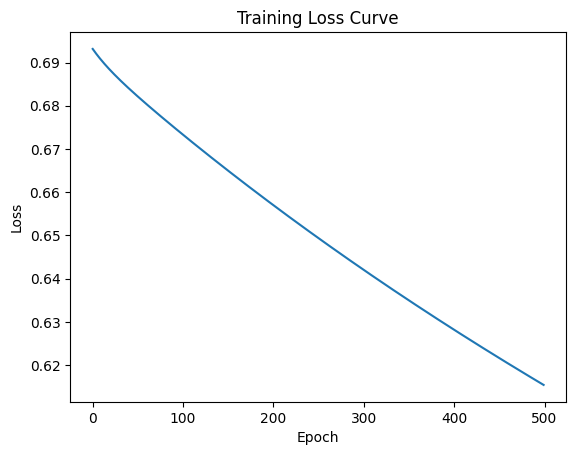

In [9]:
# Plot the loss value across training epochs
plt.plot(scratch_model.loss_history)
plt.title('Training Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

## Train the Baseline Model (using `sckit-learn`)

Train a Logistic Regression model using scikit-learn with default settings. This baseline model serves as a reference for comparing the performance of the custom implementation and the tuned model.

In [10]:
# Initialize the baseline Logistic Regression model
baseline_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# Train the model on the training set
baseline_model.fit(X_train, y_train)

# Generate predictions on the test set
baseline_pred = baseline_model.predict(X_test)

# Calculate classification metrics
baseline_accuracy = accuracy_score(y_test, baseline_pred)
baseline_precision = precision_score(y_test, baseline_pred)
baseline_recall = recall_score(y_test, baseline_pred)
baseline_f1 = f1_score(y_test, baseline_pred)

### Hyperparameter Tuning

Use Grid Search with 5-fold Cross-Validation to identify the optimal combination of hyperparameters for Logistic Regression. The model is evaluated using the F1-score to achieve a balance between Precision and Recall.

In [11]:
param_grid = {
    'C':[0.01,0.1,1,10,100],
    'solver':['liblinear','lbfgs'],
    'max_iter':[1000,2000]
}

# Perform grid search with 5-fold cross-validation
grid_search = GridSearchCV(
    LogisticRegression(random_state=42),
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

# Retrieve the best model
best_model = grid_search.best_estimator_

# Display the best hyperparameters and cross-validation score
print(grid_search.best_params_)
print(grid_search.best_score_)

{'C': 10, 'max_iter': 1000, 'solver': 'liblinear'}
0.9849121270856053


### Cross-Validation Performance

Evaluate the tuned Logistic Regression model using 5-fold Cross-Validation. The mean F1-score measures overall performance, while the standard deviation indicates the model's stability across different folds.

In [12]:
# Evaluate model stability using 5-fold cross-validation
cv_scores = cross_val_score(
    best_model,
    X_train,
    y_train,
    cv=5,
    scoring='f1'
)

# Display cross-validation results
print('Mean CV F1:', cv_scores.mean())
print('STD CV F1 :', cv_scores.std())

Mean CV F1: 0.9849121270856053
STD CV F1 : 0.002451173750061386


### Evaluating the Tuned Model

Assess the performance of the optimized Logistic Regression model on the test dataset. Key classification metrics and a detailed classification report are used to evaluate the model's predictive capability.

In [13]:
# Generate predictions on the test set
y_pred = best_model.predict(X_test)

# Calculate classification metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Display model performance
print(f'Accuracy : {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall   : {recall:.4f}')
print(f'F1 Score : {f1:.4f}')

# Display the detailed classification report
print(classification_report(y_test, y_pred))

Accuracy : 0.9828
Precision: 0.9774
Recall   : 0.9865
F1 Score : 0.9820
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      2885
           1       0.98      0.99      0.98      2592

    accuracy                           0.98      5477
   macro avg       0.98      0.98      0.98      5477
weighted avg       0.98      0.98      0.98      5477



In [14]:
metrics_logistic_regression = {
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1_Score': f1
}

save_model_package(
    model=best_model,                                  
    model_name="Logistic Regression",    
    best_params={'C': 10, 'max_iter': 1000, 'solver': 'lbfgs'},
    metrics=metrics_logistic_regression
)

'models\\Logistic_Regression.pkl'

### Confusion Matrix

Visualize the classification results using a confusion matrix. This helps identify correctly classified emails as well as false positives and false negatives.

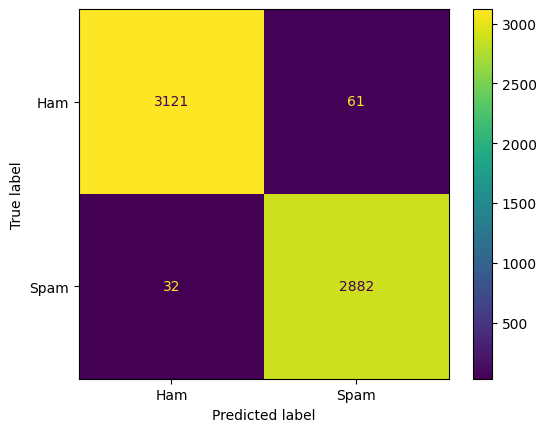

In [11]:
# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize prediction results
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Ham', 'Spam']
).plot()

plt.show()

## Performance Comparison

Compare the evaluation results of the custom Logistic Regression implementation from scratch and the optimized scikit-learn model across key classification metrics.

In [12]:
# Compare the performance of both implementations
comparison = pd.DataFrame({
    'Metric':['Accuracy','Precision','Recall','F1'],
    'Scratch':[scratch_accuracy, scratch_precision, scratch_recall, scratch_f1],
    'Scikit-Learn':[accuracy, precision, recall, f1]
})

comparison

,Metric,Scratch,Scikit-Learn
0,Accuracy,0.960138,0.984744
1,Precision,0.971741,0.979273
2,Recall,0.944063,0.989019
3,F1,0.957702,0.984122



## Statistical Interpretation of Logistic Regression

Logistic Regression is a probabilistic classification algorithm. Instead of directly predicting a class label, it estimates the probability that an email belongs to the Spam class.

### Sigmoid Function

The sigmoid function transforms a linear combination of features into a probability value between 0 and 1.

### Binary Cross-Entropy Loss

The model learns by minimizing Binary Cross-Entropy Loss using Gradient Descent. During training, weights are iteratively updated to reduce prediction error.

### Why Hyperparameter Tuning and Cross-Validation?

Hyperparameter Tuning is performed to identify the best parameter combination on the training data.

Cross-Validation provides a statistically reliable estimate of model performance by evaluating the model on multiple folds rather than a single train-validation split. This reduces selection bias and helps choose a model that generalizes better to unseen data.



## Hyperparameter Tuning and Overfitting / Underfitting Analysis

After Grid Search, analyze:

- Best Parameters (`best_params_`)
- Best Cross-Validation Score (`best_score_`)
- Mean Cross-Validation F1 Score
- Test F1 Score

Interpretation:

- CV F1 ≈ Test F1 → Good Generalization
- CV F1 >> Test F1 → Potential Overfitting
- CV F1 low and Test F1 low → Underfitting

A small difference between Cross-Validation and Test performance suggests that the model learned meaningful patterns rather than memorizing the training data.


In [14]:

print('Best Parameters:', grid_search.best_params_)
print('Best CV Score  :', grid_search.best_score_)

gap = abs(cv_scores.mean() - f1)

print(f'CV F1 Score   : {cv_scores.mean():.4f}')
print(f'Test F1 Score : {f1:.4f}')
print(f'Gap           : {gap:.4f}')

if gap < 0.02:
    print('Interpretation: No significant overfitting. Good generalization ability.')
elif cv_scores.mean() > f1:
    print('Interpretation: Potential overfitting detected.')
else:
    print('Interpretation: Model may be underfitting or unstable.')


Best Parameters: {'C': 10, 'max_iter': 1000, 'solver': 'lbfgs'}
Best CV Score  : 0.9840509525137151
CV F1 Score   : 0.9841
Test F1 Score : 0.9841
Gap           : 0.0001
Interpretation: No significant overfitting. Good generalization ability.


## Production Considerations

The Scratch Logistic Regression implementation was developed to understand the internal mechanics of the algorithm, including gradient descent optimization, weight updates, and probability estimation.

In real-world production systems, Scikit-Learn implementations are preferred because they are highly optimized using low-level numerical libraries (C/C++ backends), provide better computational efficiency, improved stability, and easier maintenance.


## Unseen Data and Deployment Discussion

Although the model performs well on the held-out test set, no machine learning model can guarantee perfect performance on future unseen emails.

Potential challenges in production:

- Data Drift: Spam patterns evolve over time.
- Distribution Shift: Real-world emails may differ from training data.
- Emerging Spam Techniques: New spam strategies may not exist in the current dataset.

To maintain performance:

- Monitor prediction quality after deployment.
- Periodically retrain the model with new email samples.
- Re-run Hyperparameter Tuning when sufficient new data becomes available.

Therefore, strong test performance increases confidence, but does not guarantee identical performance on all future unseen data.


## Final Conclusion

- Logistic Regression From scratch successfully demonstrates how the learning algorithm works internally.
- Scikit-Learn Logistic Regression achieves similar or better performance while requiring significantly less development effort.
- Hyperparameter tuning using GridSearchCV improves model generalization.
- A single 5-Fold Cross Validation evaluation is sufficient to estimate model robustness.
- For deployment and production environments, the Scikit-Learn implementation should be selected due to its optimization, scalability, and reliability.
